<a href="https://colab.research.google.com/github/BagusWichaksono/PCVK_Ganjil_2026/blob/main/Modul1_TugasKelompok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Tugas Kelompok — Penutupan Presisi Elemen Terpisah pada KTM (Kelompok 6)**

Pada tugas kelompok ini, saya memilih pengerjaan tugas **Kelompok 6**, yaitu melakukan manipulasi dan penutupan (*masking/censoring*) pada 3 bagian informasi berukuran kecil dan terpisah pada `KTM.jpg`:
1. **Tulisan "Month/Year"**
2. **Tulisan "Valid Thru"**
3. **Angka Masa Validitas (Masa Berlaku)**

Tugas ini membutuhkan tingkat ketelitian koordinat yang tinggi agar hanya menutupi area teks spesifik tanpa merusak visual latar belakang kartu. Penutupan dilakukan menggunakan kombinasi kreasi bentuk geometri (`cv.rectangle` dan `cv.circle`) dengan skema warna RGB yang kontras.

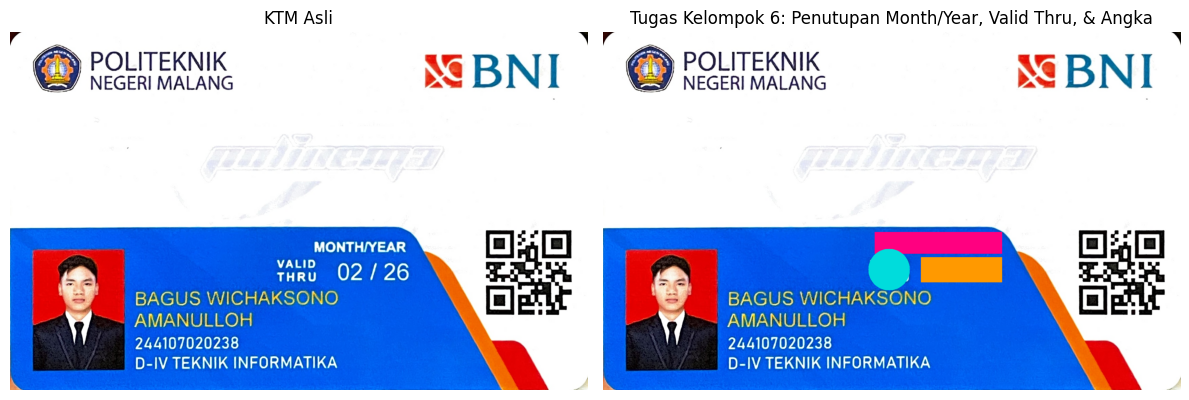

In [6]:
import cv2 as cv
import matplotlib.pyplot as plt

path_ktm = '/content/drive/MyDrive/PCVK/KTM.jpg'
img_ktm = cv.imread(path_ktm)

if img_ktm is None:
  print("Error: Berkas 'KTM.jpg' tidak ditemukan di path Drive!")
else:
  img_ktm_rgb = cv.cvtColor(img_ktm, cv.COLOR_BGR2RGB)
  img_masked = img_ktm_rgb.copy()

  h, w, _ = img_masked.shape

  # 1. Teks "MONTH/YEAR" (Magenta) - Sudah Pas
  cv.rectangle(
      img_masked,
      pt1=(int(w * 0.47), int(h * 0.56)),
      pt2=(int(w * 0.69), int(h * 0.62)),
      color=(255, 0, 128),
      thickness=-1,
  )

  # 2. Teks "VALID THRU" (Cyan) - Radius Diperbesar & Titik Pusat Diturunkan
  center_valid = (int(w * 0.495), int(h * 0.665))
  radius_valid = int(h * 0.058)  # Radius diperbesar dari 0.045 ke 0.058

  cv.circle(
      img_masked,
      center=center_valid,
      radius=radius_valid,
      color=(0, 220, 220),
      thickness=-1,
  )

  # 3. Angka "02 / 26" (Oranye) - Sudah Pas
  cv.rectangle(
      img_masked,
      pt1=(int(w * 0.55), int(h * 0.63)),
      pt2=(int(w * 0.69), int(h * 0.70)),
      color=(255, 153, 0),
      thickness=-1,
  )

  plt.figure(figsize=(12, 6))

  plt.subplot(1, 2, 1)
  plt.imshow(img_ktm_rgb)
  plt.title('KTM Asli')
  plt.axis('off')

  plt.subplot(1, 2, 2)
  plt.imshow(img_masked)
  plt.title('Tugas Kelompok 6: Penutupan Month/Year, Valid Thru, & Angka')
  plt.axis('off')

  plt.tight_layout()
  plt.show()

**Penjelasan Logika Kode & Analisis (Kelompok 6):**

1. **Pembacaan & Konversi Format Citra**:
   Gambar `KTM.jpg` dibaca dari Google Drive menggunakan `cv.imread()`. Konversi warna dilakukan dari format BGR ke RGB menggunakan `cv.cvtColor()` agar warna gambar yang ditampilkan Matplotlib sesuai dengan citra aslinya.

2. **Proses Penutupan Elemen Informasi (Masking)**:
   * **Teks "MONTH/YEAR"**: Ditutup menggunakan `cv.rectangle()` berwarna Magenta `(255, 0, 128)`.
   * **Teks "VALID THRU"**: Ditutup secara penuh menggunakan `cv.circle()` berwarna Cyan `(0, 220, 220)` dengan radius yang diperbesar (`0.058 * h`) untuk menutupi teks dua baris (vertikal) secara presisi.
   * **Angka Masa Berlaku ("02 / 26")**: Ditutup menggunakan `cv.rectangle()` berwarna Oranye `(255, 153, 0)`.

3. **Penggunaan Sistem Koordinat Relatif**:
   Seluruh koordinat (`pt1`, `pt2`, dan `center`) dihitung secara dinamis menggunakan rasio persentase dari dimensi lebar (`w`) dan tinggi (`h`) gambar. Hal ini memastikan posisi dan ukuran bentuk penutup tetap presisi meskipun skala atau resolusi gambar KTM berubah.